In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import math

### Data cleaning

In [2]:
df = pd.read_csv("ratings.csv")

df_est = df.copy()

df_est["ortg"] = (df_est["ortg"] - df_est["ortg"].mean()) / df_est["ortg"].std()
df_est["drtg"] = (df_est["drtg"] - df_est["drtg"].mean()) / df_est["drtg"].std()
df_est["netrtg"] = (df_est["netrtg"] - df_est["netrtg"].mean()) / df_est["netrtg"].std()
df_est["proj_wins"] = 2 * (df_est["proj_wins"] - df_est["proj_wins"].mean()) / df_est["proj_wins"].std()

### Modelo con victorias esperadas

In [3]:
kmeans = KMeans(n_clusters=4, random_state=0)

In [6]:
x = df_est[["netrtg","proj_wins"]]
kmeans.fit(x)

df["cluster"] = kmeans.labels_
df.to_csv("ratings_cluster.csv")
df.sort_values(by="proj_wins",ascending=False)

/Users/juandiazarenascolegio/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,team,ortg,drtg,netrtg,proj_wins,cluster
14,Oklahoma City Thunder,120.3,107.5,12.8,62.5,3
18,Cleveland Cavaliers,121.7,112.2,9.5,56.5,3
10,Denver Nuggets,119.9,116.0,3.9,53.5,3
1,New York Knicks,118.5,114.3,4.2,53.5,3
13,Houston Rockets,115.3,110.8,4.6,52.5,3
27,Orlando Magic,109.4,109.6,-0.1,51.5,0
24,Minnesota Timberwolves,116.6,111.5,5.1,49.5,0
17,Los Angeles Clippers,115.1,110.3,4.7,49.5,0
2,Golden State Warriors,115.0,111.7,3.3,47.5,0
6,Atlanta Hawks,114.6,115.7,-1.1,47.5,0


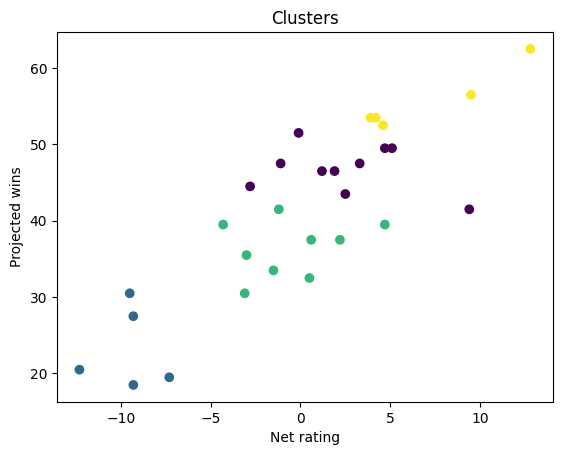

In [35]:
plt.scatter(df["netrtg"], df["proj_wins"], c=df["cluster"])
plt.xlabel("Net rating")
plt.ylabel("Projected wins")
plt.title("Clusters")
plt.show()

In [37]:
df.groupby(by="cluster")["netrtg"].mean()

cluster
0    2.410000
1   -9.540000
2   -0.566667
3    7.000000
Name: netrtg, dtype: float64

In [52]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

net_embiid = 5.4
net_not_embiid = -3.7

poss = 98.17
# Standard deviation of possessions per game
sigma = 12

# Añadir algo en casa y fuera
# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

# Differences of net ratings with clusters if Embiid plays or not
diffs_embiid = [net_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_not_embiid = [net_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_embiid]
win_not_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_not_embiid]

win_probs, win_not_probs

# Against cluster 1: 14
# Against cluster 2: 28
# Against cluster 3: 25
# Against cluster 4: 15

# Todos oeste -> 2 partidos (30)
# Todos division (Raptors, Celtics, Knicks, Nets) -> 4 partidos (16)
# Resto -> Contra 6 4 partidos, contra 4 3 partidos (36)
# Magic –> 3
# Heat –> 3
# Wizards -> 4
# Hornets -> 3
# Hawks -> 3
# Bulls -> 3 (+1)
# Bucks -> 4
# Pacers -> 3 (+1)
# Cavs -> 4
# Pistons -> 4

# Cluster nuevo
# Con Embiid -> 53 victorias en 82 partidos
# Sin Embiid -> 31 victorias en 82 partidos

([0.5966195959965248,
  0.8891871170976309,
  0.6872686593350312,
  0.44792984426918747],
 [0.30859073193802977,
  0.6835897202682024,
  0.39884694475545124,
  0.1906919748271284])

### Modelo muy basado en temporada anterior

In [48]:
kmeans_alt = KMeans(n_clusters=4, random_state=0)
x_alt = df_est[["ortg","drtg","netrtg"]]
kmeans_alt.fit(x_alt)

/Users/juandiazarenascolegio/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4, random_state=0)

In [49]:
df_alt = df.copy()
df_alt["cluster"] = kmeans_alt.labels_
df_alt

,team,ortg,drtg,netrtg,proj_wins,cluster
0,Boston Celtics,120.6,111.1,9.4,41.5,3
1,New York Knicks,118.5,114.3,4.2,53.5,0
2,Golden State Warriors,115.0,111.7,3.3,47.5,0
3,Detroit Pistons,115.0,113.1,1.9,46.5,0
4,Los Angeles Lakers,115.9,114.7,1.2,46.5,0
5,Sacramento Kings,116.7,116.2,0.5,32.5,2
6,Atlanta Hawks,114.6,115.7,-1.1,47.5,2
7,Washington Wizards,106.8,119.1,-12.3,20.5,1
8,Chicago Bulls,114.1,115.6,-1.5,33.5,2
9,San Antonio Spurs,114.4,117.2,-2.8,44.5,2


In [50]:
df_alt.groupby(by="cluster")["netrtg"].mean()

cluster
0     2.984615
1    -9.540000
2    -2.062500
3    10.566667
Name: netrtg, dtype: float64

In [53]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

net_embiid = 5.4
net_not_embiid = -3.7

poss = 98.17
# Standard deviation of difference of points per game
# Con 12 funciona bastante bien
sigma = 12

# Suponiendo que el margen real sigue (aprox.) una distribución normal, 
# la probabilidad de ganar es la probabilidad de que el margen sea > 0

# Añadir algo en casa y fuera
# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

# Differences of net ratings with clusters if Embiid plays or not
diffs_embiid = [net_embiid - net for net in df_alt.groupby(by="cluster")["netrtg"].mean()]
diffs_not_embiid = [net_not_embiid - net for net in df_alt.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_embiid]
win_not_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_not_embiid]

win_probs, win_not_probs

# Cluster antiguo
# Con Embiid -> 51 victorias en 80 partidos
# Sin Embiid -> 30/31 victorias en 80 partidos

([0.5783204308644903,
  0.8891871170976309,
  0.7292329192536074,
  0.3362656922934797],
 [0.2922384060352695,
  0.6835897202682024,
  0.446716649286113,
  0.12157848850214237])

### Separación casa/fuera

In [ ]:
# The 76ers have 98.17 possessions per game bewteen the 20-21 and 24-25 seasons
# Average league possessions is 99-100 per game
# We can use net rating to estimate the probability of the 76ers winning against the different clusters

# Record con Embiid en casa: 94-37. Net rating: 6.4
# Record sin Embiid en casa: 25-44. Net rating: -3.7
# Record con Embiid fuera: 72-40. Net rating: 4.2
# Record sin Embiid fuera: 34-54. Net rating: -3.8

net_home_embiid = 6.4
net_home_not_embiid = -3.7
net_away_embiid = 4.2
net_away_not_embiid = -3.8

poss = 98.17
# Standard deviation of difference of points per game
# Con 12 funciona bastante bien
sigma = 12

# Todos oeste -> 2 partidos (30)
# Todos division (Raptors, Celtics, Knicks, Nets) -> 4 partidos (16)
# Resto -> Contra 6 4 partidos, contra 4 3 partidos (36)
# Magic –> 3
# Heat –> 3 (+1)
# Wizards -> 4
# Hornets -> 3
# Hawks -> 3
# Bulls -> 3
# Bucks -> 4
# Pacers -> 3 (+1)
# Cavs -> 4
# Pistons -> 4

# Hay que poner como constraint que no juegue en Denver por favor
# Lleva sin jugar desde el 8 de noviembre de 2019 🤣

In [ ]:
# At home: 41
# Against cluster 1: 7
# Against cluster 2: 15
# Against cluster 3: 12
# Against cluster 4: 7

# Differences of net ratings with clusters if Embiid plays or not AT HOME
diffs_home_embiid = [net_home_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_home_not_embiid = [net_home_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_home_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_home_embiid]
win_home_not_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_home_not_embiid]

win_home_embiid_probs, win_home_not_embiid_probs

# En casa con Embiid: 27/28 victorias de 41
# En casa sin Embiid: 15/16 victorias de 41

([0.6279448994938123,
  0.9038874422925967,
  0.7156378828027741,
  0.4804257786319578],
 [0.30859073193802977,
  0.6835897202682024,
  0.39884694475545124,
  0.1906919748271284])

In [ ]:
# Away: 41
# Against cluster 1: 7
# Against cluster 2: 13
# Against cluster 3: 13
# Against cluster 4: 8

# Differences of net ratings with clusters if Embiid plays or not AWAY
diffs_away_embiid = [net_away_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]
diffs_away_not_embiid = [net_away_not_embiid - net for net in df.groupby(by="cluster")["netrtg"].mean()]

# Win probabilities against every cluster with and without Embiid
win_away_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_away_embiid]
win_away_not_embiid_probs = [0.5 * (1 + math.erf((diff * poss/100)/sigma / math.sqrt(2))) for diff in diffs_away_not_embiid]

win_away_embiid_probs, win_away_not_embiid_probs

# Fuera con Embiid: 25/26 victorias de 41
# Fuera sin Embiid: 15/16 victorias de 41

([0.5582117569389846,
  0.8695033501188124,
  0.6517143697163756,
  0.40940984578293965],
 [0.30571623988778884,
  0.6806723822265628,
  0.3956920890266532,
  0.18847499049271899])

In [ ]:
# Total: 
# Con Embiid: 54/56 victorias de 82
# Sin Embiid: 30/32 victorias de 82

### Ideas de constraints

In [ ]:
# Si Embiid juega menos de 24-27 minutos es como si no jugara
# A partir de ahí regresión lineal hasta 36-37-38 minutos -> va aumentando la probabilidad según juegue más
# Embiid tiene 33.1 minutos por partido entre las temporadas 20-21 y 24-25
# Su máximo en una temporada son 34.6 en la 22-23, cuando fue MVP
# Si juega más de X minutos en un partido no puede jugar el siguiente
# Los 76ers deben ganar un número mínimo de partidos para clasificar a playoffs
# Partidos de copa -> Embiid tiene que jugarlos obligatoriamente -> sanción
# Si juega menos minutos de los que le gustaría en la temporada pedirá el traspaso
# No puede jugar en Denver